# Import libraries

In [121]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np

import tensorflow as tf
import crepe
import pesto

import torch
import torchaudio
from rmvpe import RMVPE

# PYIN is implemented in Librosa
# CREPE: pip install crepe
# PESTO: pip install pesto-pitch
# RMVPE: download "rmvpe.pt' file from "https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main/rmvpe.pt" and load it as below 
device = "cuda" if torch.cuda.is_available() else "cpu"
model_rmvpe = RMVPE("rmvpe.pt", is_half=False, device=device)

# Pitch Estimation

In [120]:

SR = 16000
STEP_SIZE_MS = 10
HOP_LENGTH = 160  # 16000Hz * 0.01s
audio_path = "../audio/Heyyeahyeah.wav"
#audio_path = "../audio/Beatles_yesterday.wav"
#audio_path = "../audio/Beatles_yesterday_vocal.wav"
#audio_path = "../audio/Sumi_Jo_-_Queen_of_the_night_audio_short.wav"

y, _ = librosa.load(audio_path, sr=SR)

# (1) PYIN
f0_pyin, voiced_flag, _ = librosa.pyin(y, sr=SR, fmin=100, fmax=1000, hop_length=HOP_LENGTH)
t_pyin = librosa.times_like(f0_pyin, sr=SR, hop_length=HOP_LENGTH)

# (2) CREPE
t_crepe, f0_crepe, conf_crepe, _ = crepe.predict(y, SR, step_size=STEP_SIZE_MS, viterbi=True, verbose=False)
t_crepe = t_crepe / 1000.0

# (3) PESTO
y_torch = torch.from_numpy(y).float().unsqueeze(0)
t_pesto, f0_pesto, conf_pesto, _ = pesto.predict(y_torch, SR, step_size=STEP_SIZE_MS)
t_pesto = t_pesto / 1000.0

f0_pesto = np.array(f0_pesto).flatten()
conf_pesto = np.array(conf_pesto).flatten()

# (4) RMVPE
f0_rmvpe = model_rmvpe.infer_from_audio(y, thred=0.03)
f0_rmvpe = f0_rmvpe.detach().cpu().numpy().flatten() if torch.is_tensor(f0_rmvpe) else np.array(f0_rmvpe).flatten()
t_rmvpe = librosa.times_like(f0_rmvpe, sr=SR, hop_length=HOP_LENGTH)


# Visualization

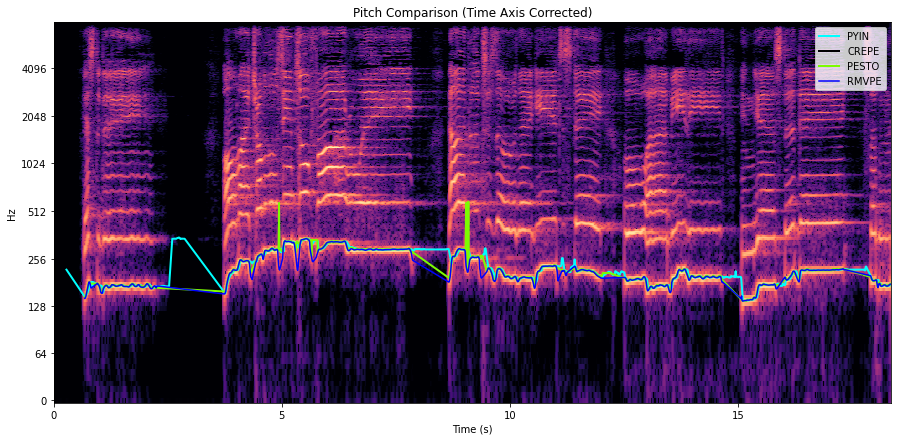

In [115]:
plt.figure(figsize=(15, 7))

D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=HOP_LENGTH)), ref=np.max)

img = librosa.display.specshow(D, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='log', cmap='magma')

def plot_pitch(t, f, conf, label, color, thresh=0.3, style='-'):
    if f.size == 0: return

    f_masked = np.copy(f)
    f_masked[conf < thresh] = 0
    
    mask = f_masked > 0
    plt.plot(t[mask], f_masked[mask], label=label, color=color, linestyle=style, linewidth=2)


plt.plot(t_pyin[voiced_flag], f0_pyin[voiced_flag], label='PYIN', color='cyan', linewidth=2)
plot_pitch(t_crepe, f0_crepe, conf_crepe, 'CREPE', 'black', thresh=0.5)
plot_pitch(t_pesto, f0_pesto, conf_pesto, 'PESTO', 'lawngreen', thresh=0.35)
plt.plot(t_rmvpe[f0_rmvpe > 0], f0_rmvpe[f0_rmvpe > 0], label='RMVPE', color='blue', linewidth=1.5)

#plt.ylim(100, 1000)
plt.xlim(0, len(y)/SR) 
plt.title("Pitch Comparison (Time Axis Corrected)")
plt.xlabel("Time (s)")
plt.legend(loc='upper right')
plt.show()

# Sonification

In [119]:
import numpy as np
import IPython.display as ipd

def synthesize_sine_from_f0(f0, sr, hop_length):

    # 1. interplate f0 sequence to sample units using linear interpolation 
    total_samples = len(f0) * hop_length
    f0_resampled = np.interp(
        np.arange(total_samples), 
        np.arange(len(f0)) * hop_length, 
        f0
    )
    
    # 2. Cumulative Phase 
    # Phase = 2 * pi * integral(f(t) dt)
    phase = 2 * np.pi * np.cumsum(f0_resampled) / sr
    
    # 3. Sine Generation
    audio_synth = np.sin(phase)
        
    return audio_synth


audio_pyin = synthesize_sine_from_f0(f0_pyin[voiced_flag], SR, HOP_LENGTH)

audio_crepe = synthesize_sine_from_f0(f0_crepe, SR, HOP_LENGTH)

audio_pesto = synthesize_sine_from_f0(f0_pesto, SR, HOP_LENGTH)

audio_rmvpe = synthesize_sine_from_f0(f0_rmvpe, SR, HOP_LENGTH)


ipd.Audio(audio_crepe, rate=SR)